# Tapered UCCSD doubles picker + verification (default HF)

Pick which UCCSD **double excitations** to keep for a molecule, then verify that
running them in the **qubit-tapered** register (2 fewer qubits) is exact and
reaches chemical accuracy across the bond grid.

Pipeline context:
- `generate_tapered_hamiltonians.py` writes the tapered Hamiltonians to `state_transfer/Pauli_Ham/`.
- This notebook selects the doubles and checks the tapered single-string ansatz.
- `generate_tapered_circuits.py` compiles the chosen doubles into the fixed-pair RZX circuit.

Everything is molecule-generic: change `MOLECULE` in the config cell to `"Cl2"` or
`"Br2"` (presets come from `June_main/generate_molecular_hamiltonians.py`).

Key idea (why tapering keeps UCCSD exact): tapering is a Clifford map `U`, so
`U exp(-i t/2 P) U+ = exp(-i t/2 UPU+)`. Each symmetry-respecting double's
Jordan-Wigner string `P` maps to a single tapered Pauli `P~` (times a sign), and
the reference HF determinant maps to a determinant on the kept qubits. The
tapered ansatz is therefore the *same* variational family on fewer qubits.

In [1]:
# === Config cell: choose molecule + doubles (default HF) ===
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
while not (REPO / "June_main").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
for _p in (REPO / "June_main", REPO / "state_transfer", REPO / "UCCSD circuit"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import numpy as np
import generate_molecular_hamiltonians as gm

MOLECULE = "HF"  # <-- change to "Cl2" or "Br2" later
PRESET = gm.MOLECULE_PRESETS[MOLECULE]
active_space = PRESET.active_space
N_SPATIAL = active_space[1]
N_ELEC = active_space[0]
d_grid = np.round(np.array(PRESET.default_bonds, dtype=float), 4)
top_k = 3

# Paper spin-block-layout doubles (a_k^dag a_l^dag a_i a_j) to keep. Defaults are
# the top-k shared-creation set from the matching UCCSD_Mole notebook. Edit after
# inspecting the MP2 ranking table below.
PAPER_DOUBLES = {
    "HF": [(3, 7, 4, 0), (3, 7, 5, 1), (3, 7, 6, 2)],
    "Cl2": [(4, 9, 6, 1), (4, 9, 5, 0), (4, 9, 7, 2)],
    "Br2": [(5, 11, 6, 0), (5, 11, 10, 4), (5, 11, 9, 3), (5, 11, 8, 2)],
}[MOLECULE]

print(f"MOLECULE={MOLECULE}  active_space={active_space}  "
      f"({N_ELEC}e, {N_SPATIAL}o -> {2*N_SPATIAL} qubits -> {2*N_SPATIAL-2} tapered)")
print(f"bond grid (A): {d_grid.tolist()}")
print(f"doubles to keep: {PAPER_DOUBLES}")

/Users/zacharyhe/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


MOLECULE=HF  active_space=(6, 4)  (6e, 4o -> 8 qubits -> 6 tapered)
bond grid (A): [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2]
doubles to keep: [(3, 7, 4, 0), (3, 7, 5, 1), (3, 7, 6, 2)]


In [2]:
# === Shared helpers: openfermion Hamiltonian, tapering, single-string ansatz ===
import importlib.util
import warnings

warnings.filterwarnings("ignore")
from scipy.optimize import minimize
from scipy.sparse.linalg import expm_multiply
from openfermion.linalg import get_sparse_operator

import taper_lib
from tencirchem import UCCSD, M

_spec = importlib.util.spec_from_file_location(
    "gen", str(REPO / "UCCSD circuit" / "improved create UCCSD circuit .py")
)
gen = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(gen)


def make_mol(d):
    """TenCirChem molecule from the preset geometry."""
    atoms = [[sym, float(x), float(y), float(z)]
             for sym, (x, y, z) in PRESET.geometry_factory(float(d))]
    return M(atom=atoms, basis=PRESET.basis, unit="Angstrom")


def hf_state_vector(n_qubits, occupied):
    """Computational-basis HF determinant (openfermion qubit-0 = MSB order)."""
    index = 0
    for q in occupied:
        index |= 1 << (n_qubits - 1 - q)
    vec = np.zeros(2 ** n_qubits, dtype=complex)
    vec[index] = 1.0
    return vec


def _string_sparse(string, n_qubits):
    return get_sparse_operator(
        taper_lib.pauli_string_to_qubit_operator(string), n_qubits=n_qubits
    )


def optimize_single_string_ansatz(H_sparse, hf_vec, strings, signs, n_qubits):
    """Optimize prod exp(-i sign*theta/2 P) |HF> against H (statevector)."""
    pauli_sparse = [_string_sparse(s, n_qubits) for s in strings]

    def energy(theta):
        v = hf_vec.copy()
        for t, sg, P in zip(theta, signs, pauli_sparse):
            v = expm_multiply(-0.5j * float(t) * float(sg) * P, v)
        return float(np.real(np.vdot(v, H_sparse @ v)))

    res = minimize(energy, np.zeros(len(strings)), method="BFGS",
                   options={"gtol": 1e-9})
    return float(res.fun), np.asarray(res.x)


def build_full_and_tapered(d):
    """Full-register openfermion Hamiltonian + tapered Hamiltonian + TaperData."""
    H_full, _ = gm.build_molecular_hamiltonian(MOLECULE, float(d))
    taper = taper_lib.build_taper_data(N_SPATIAL, N_ELEC)
    H_tap = taper_lib.taper_qubit_operator(H_full, taper)
    return H_full, H_tap, taper


print("helpers ready")

helpers ready


In [3]:
# === MP2 top-k doubles ranking (TenCirChem) so you can pick doubles ===
# Same selection logic as UCCSD_Mole/HF.ipynb. The op_terms are in TenCirChem's
# internal qubit order; the paper spin-block-layout indices used by the circuit
# generator are in PAPER_DOUBLES above.
import pandas as pd


def build_reduced_topk_doubles_ucc(mol, active_space, k, fixed_pids=None):
    probe = UCCSD(mol, active_space=active_space, init_method="mp2",
                  pick_ex2=False, sort_ex2=False, run_fci=False)
    all_ops = probe.ex_ops
    all_param_ids = probe.param_ids
    all_init_guess = probe.init_guess

    pid_to_ops = {}
    for op, pid in zip(all_ops, all_param_ids):
        pid_to_ops.setdefault(pid, []).append(op)
    double_pids = [pid for pid, ops in pid_to_ops.items() if all(len(op) == 4 for op in ops)]
    if not double_pids:
        raise ValueError("No double-excitation parameters found.")

    pid_to_guess = {pid: all_init_guess[pid] for pid in double_pids}
    if fixed_pids is None:
        selected_pids = sorted(double_pids, key=lambda p: abs(pid_to_guess[p]), reverse=True)[:k]
    else:
        selected_pids = list(fixed_pids)

    selected_set = set(selected_pids)
    selected_ex_ops, selected_param_ids = [], []
    selected_pid_to_ops = {pid: [] for pid in selected_pids}
    for op, pid in zip(all_ops, all_param_ids):
        if pid in selected_set:
            selected_ex_ops.append(op)
            selected_param_ids.append(pid)
            selected_pid_to_ops[pid].append(op)
    pid_remap = {old: new for new, old in enumerate(selected_pids)}
    selected_param_ids = [pid_remap[p] for p in selected_param_ids]

    reduced = UCCSD(mol, active_space=active_space, init_method="zeros",
                    pick_ex2=False, sort_ex2=False, run_fci=False)
    reduced.ex_ops = selected_ex_ops
    reduced.param_ids = selected_param_ids
    reduced.init_guess = [0.0 for _ in selected_pids]

    def op_to_string(op):
        p, q, r, s = op
        return f"a{p}dag a{q}dag a{r} a{s}"

    rows = []
    for rank, pid in enumerate(selected_pids, start=1):
        rows.append({
            "rank": rank,
            "param_id_index": pid,
            "mp2_init_theta": pid_to_guess[pid],
            "abs_mp2_init_theta": abs(pid_to_guess[pid]),
            "n_ex_ops_linked": len(selected_pid_to_ops[pid]),
            "op_terms": " | ".join(op_to_string(op) for op in selected_pid_to_ops[pid]),
        })
    return reduced, selected_pids, selected_ex_ops, pd.DataFrame(rows)


report_d = float(d_grid[0])
_reduced, _pids, _ex_ops, ranking_df = build_reduced_topk_doubles_ucc(
    make_mol(report_d), active_space, top_k
)
print(f"Top-{top_k} doubles ranked by |MP2 theta| at d = {report_d:.2f} A")
print(f"Circuit uses PAPER_DOUBLES (spin-block layout) = {PAPER_DOUBLES}")
ranking_df

Top-3 doubles ranked by |MP2 theta| at d = 1.00 A
Circuit uses PAPER_DOUBLES (spin-block layout) = [(3, 7, 4, 0), (3, 7, 5, 1), (3, 7, 6, 2)]


,rank,param_id_index,mp2_init_theta,abs_mp2_init_theta,n_ex_ops_linked,op_terms
0,1,3,-0.085483,0.085483,1,a3dag a7dag a4 a0
1,2,5,-0.015343,0.015343,1,a3dag a7dag a5 a1
2,3,8,-0.015343,0.015343,1,a3dag a7dag a6 a2


In [4]:
# === Bond-scan verification: tapering is exact + reaches chemical accuracy ===
# For each bond length compare:
#   e_full_ss  : single-string doubles ansatz on the FULL register
#   e_tap_ss   : same ansatz on the TAPERED register (must equal e_full_ss)
#   e_tc_topk  : TenCirChem spin-adapted top-k UCCSD (context)
#   e_fci      : active-space FCI (chemical-accuracy reference)
taper = taper_lib.build_taper_data(N_SPATIAL, N_ELEC)
nqf, nqt = taper.n_qubits_full, taper.n_qubits_tapered
occ_full = [q for q, b in enumerate(taper.hf_bitstring_full) if b == "1"]
occ_tap = [q for q, b in enumerate(taper.hf_bitstring_tapered) if b == "1"]

full_strings = ["".join(gen.jw_string_for_double(nqf, dbl)) for dbl in PAPER_DOUBLES]
tapered = [taper_lib.taper_pauli_string(s, taper) for s in full_strings]
tap_strings = [t for t, _ in tapered]
tap_signs = [sg for _, sg in tapered]
print("full strings   :", full_strings)
print("tapered strings:", tap_strings, " signs:", tap_signs)

rows = []
for d in d_grid:
    H_full, H_tap, _ = build_full_and_tapered(d)
    Hf = get_sparse_operator(H_full, n_qubits=nqf)
    Ht = get_sparse_operator(H_tap, n_qubits=nqt)
    hf_f = hf_state_vector(nqf, occ_full)
    hf_t = hf_state_vector(nqt, occ_tap)

    e_full_ss, _ = optimize_single_string_ansatz(Hf, hf_f, full_strings, [1] * len(full_strings), nqf)
    e_tap_ss, _ = optimize_single_string_ansatz(Ht, hf_t, tap_strings, tap_signs, nqt)

    mol = make_mol(d)
    ucc_as = UCCSD(mol, active_space=active_space, init_method="mp2",
                   pick_ex2=True, sort_ex2=True, run_fci=True)
    ucc_as.kernel()
    e_fci = float(ucc_as.e_fci)
    reduced_d, _, _, _ = build_reduced_topk_doubles_ucc(mol, active_space, top_k)
    e_tc_topk = float(reduced_d.kernel())

    rows.append({
        "d_angstrom": float(d),
        "e_full_ss_Ha": e_full_ss,
        "e_tap_ss_Ha": e_tap_ss,
        "taper_exact_diff_mHa": (e_full_ss - e_tap_ss) * 1000.0,
        "e_tc_topk_Ha": e_tc_topk,
        "e_fci_Ha": e_fci,
        "tap_minus_fci_mHa": (e_tap_ss - e_fci) * 1000.0,
        "tc_topk_minus_fci_mHa": (e_tc_topk - e_fci) * 1000.0,
    })

scan_df = pd.DataFrame(rows)
print(f"\nmax |e_full_ss - e_tap_ss| = {scan_df['taper_exact_diff_mHa'].abs().max():.2e} mHa (tapering exactness)")
scan_df

full strings   : ['YZZXXZZX', 'IYZXIXZX', 'IIYXIIXX']
tapered strings: ['YZZXZZ', 'IYZIXZ', 'IIYIIX']  signs: [1, 1, 1]

max |e_full_ss - e_tap_ss| = 6.48e-09 mHa (tapering exactness)


,d_angstrom,e_full_ss_Ha,e_tap_ss_Ha,taper_exact_diff_mHa,e_tc_topk_Ha,e_fci_Ha,tap_minus_fci_mHa,tc_topk_minus_fci_mHa
0,1.0,-98.596939,-98.596939,-8.526513e-10,-98.597022,-98.597486,0.547357,0.464398
1,1.2,-98.572956,-98.572956,6.536993e-10,-98.573148,-98.573878,0.922818,0.730441
2,1.4,-98.533669,-98.533669,3.240075e-09,-98.533941,-98.534886,1.216117,0.944305
3,1.6,-98.499605,-98.499605,-6.821210e-10,-98.499849,-98.500993,1.387943,1.144043
4,1.8,-98.476453,-98.476453,-2.515321e-09,-98.476603,-98.477958,1.504982,1.355018
5,2.0,-98.463293,-98.463293,6.480150e-09,-98.463361,-98.464938,1.644792,1.576733
6,2.2,-98.456601,-98.456601,7.389644e-10,-98.456624,-98.458424,1.822827,1.799723


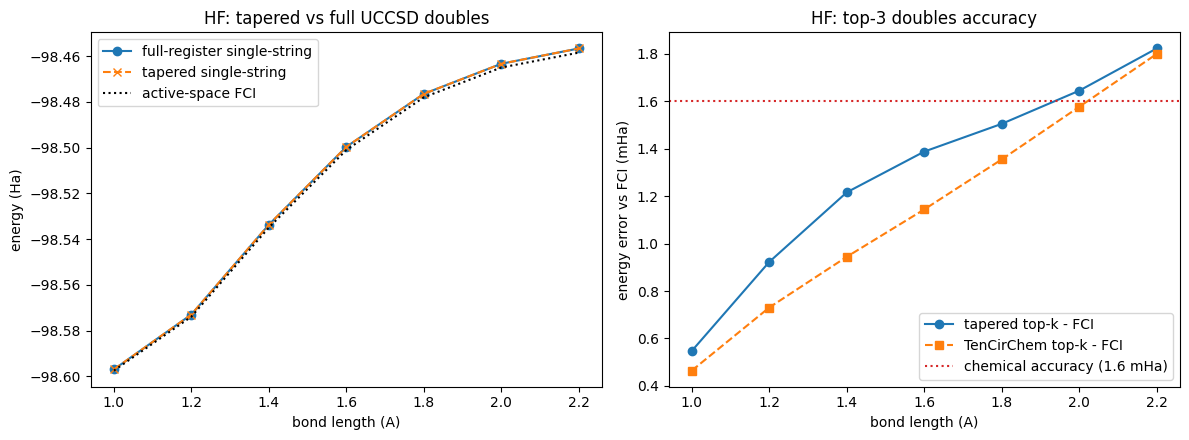

In [5]:
# === Plots ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(scan_df["d_angstrom"], scan_df["e_full_ss_Ha"], "o-", label="full-register single-string")
ax.plot(scan_df["d_angstrom"], scan_df["e_tap_ss_Ha"], "x--", label="tapered single-string")
ax.plot(scan_df["d_angstrom"], scan_df["e_fci_Ha"], "k:", label="active-space FCI")
ax.set_xlabel("bond length (A)")
ax.set_ylabel("energy (Ha)")
ax.set_title(f"{MOLECULE}: tapered vs full UCCSD doubles")
ax.legend()

ax = axes[1]
ax.plot(scan_df["d_angstrom"], scan_df["tap_minus_fci_mHa"], "o-", label="tapered top-k - FCI")
ax.plot(scan_df["d_angstrom"], scan_df["tc_topk_minus_fci_mHa"], "s--", label="TenCirChem top-k - FCI")
ax.axhline(1.6, color="tab:red", ls=":", label="chemical accuracy (1.6 mHa)")
ax.set_xlabel("bond length (A)")
ax.set_ylabel("energy error vs FCI (mHa)")
ax.set_title(f"{MOLECULE}: top-{top_k} doubles accuracy")
ax.legend()

fig.tight_layout()
plt.show()

## Notes

- **Tapering exactness**: `taper_exact_diff_mHa` is ~0 (to optimizer tolerance)
  because the tapered single-string ansatz is the same variational family as the
  full-register one, mapped by a Clifford. This is the concrete confirmation that
  qubit tapering does not degrade UCCSD accuracy.
- **Chemical accuracy**: `tap_minus_fci_mHa` shows the kept top-k doubles reach
  (or approach) the 1.6 mHa line across the scan.
- **Single-string vs TenCirChem**: the circuit uses one JW representative string
  per double (`pair=False`, cheaper and variationally equivalent on a
  determinant), which can differ slightly from TenCirChem's spin-adapted UCCSD
  (`e_tc_topk`). Both are shown for context.
- **Picking doubles**: edit `PAPER_DOUBLES` (spin-block layout `a_k^dag a_l^dag a_i a_j`,
  spin-up orbitals `0..N/2-1`, spin-down `N/2..N-1`) after inspecting the MP2
  ranking, then rerun. Feed the same list to `generate_tapered_circuits.py`.
- **Other molecules**: set `MOLECULE = "Cl2"` or `"Br2"` in the config cell; the
  active space, bond grid and tapering follow automatically.